## U-Net

### **The Architecture**
<img src="./assets/u-net-architecture.png" style="max-height:1000px; max-width:1000px" />

*Image taken from 'U-Net: Convolutional Networks for Biomedical Image Segmentation'* <br>

**U-Net** is a very important network architecture for image segmentation, having several applications, and also several modern variations.<br>
It is similar to an autoencoder, except for the presence of concatenation layers with help the model localize, and give it its U shape. <br>
We can look at the architecture as two components:
1. Encoder block- An encoder block consists of two convolutional layers and one max pooling layer for downsampling. The output from the convolutions is saved for later concatenation, before it is passed to the pooling layer.
2. Decoder block- A decoder block consists of two convolutional layers and one up convolution later for upsampling. Before the convolutions, the previously saved layer is concatenated to the input. <br>

The final mask has per-pixel likelihoods for each class.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from keras.layers import Conv2D, Concatenate, MaxPool2D, Activation, Conv2DTranspose, Input
from keras import Model

In [2]:
!nvidia-smi

Mon Jan  5 15:40:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             46W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
def _encoder_block(input, num_filters):
  out_r = Conv2D(num_filters, 3, padding='same')(input)
  out_r = Activation('relu')(out_r)

  out_r = Conv2D(num_filters, 3, padding='same')(out_r)
  out_r = Activation('relu')(out_r)
  out_d = MaxPool2D()(out_r)

  return out_r, out_d

In [4]:
def _decoder_block(input, cat_layer, num_filters):
  out_r = Concatenate()([input, cat_layer])
  out_r = Conv2D(num_filters, 3, padding='same')(out_r)
  out_r = Activation('relu')(out_r)

  out_r = Conv2D(num_filters, 3, padding='same')(out_r)
  out_r = Activation('relu')(out_r)

  out_u = Conv2DTranspose(num_filters, 2, padding='same', strides=2)(out_r)

  return out_u

In [5]:
def build_unet(input_shape):
  
  # Downsampling
  input = Input(shape=input_shape)
  r1, d1 = _encoder_block(input, 64)
  r2, d2 = _encoder_block(d1, 128)
  r3, d3 = _encoder_block(d2, 256)
  r4, d4 = _encoder_block(d3, 512)

  # Base layer
  b1 = Conv2D(filters=1024, kernel_size=3, padding='same')(d4)
  b1 = Activation('relu')(b1)

  b2 = Conv2D(filters=1024, kernel_size=3, padding='same')(b1)
  b2 = Activation('relu')(b2)

  u1 = Conv2DTranspose(512, 3, padding='same', strides=2)(b2)

  # Upsampling
  u2 = _decoder_block(u1, r4, 256)
  u3 = _decoder_block(u2, r3, 128)
  u4 = _decoder_block(u3, r2, 64)
  
  # Final step
  f1 = Concatenate()([u4, r1])
  f2 = Conv2D(filters=64, kernel_size=3, padding='same')(f1)
  f3 = Conv2D(filters=64, kernel_size=3, padding='same')(f2)
  f4 = Conv2D(filters= 3, kernel_size=3, padding='same', activation='sigmoid')(f3)

  model = Model(inputs=input, outputs=f4)
  
  return model

In [6]:
model = build_unet((256, 256, 3))

### Getting the tensorflow dataset

In [7]:
import tensorflow as tf
import tensorflow_datasets as tfds

In [8]:
dataset, info = tfds.load(
  "oxford_iiit_pet",
  with_info=True,
  as_supervised=False
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.Z0OT3I_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.Z0OT3I_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


In [9]:
dataset

{'train': <_PrefetchDataset element_spec={'file_name': TensorSpec(shape=(), dtype=tf.string, name=None), 'head_bbox': TensorSpec(shape=(4,), dtype=tf.float32, name=None), 'image': TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None), 'segmentation_mask': TensorSpec(shape=(None, None, 1), dtype=tf.uint8, name=None), 'species': TensorSpec(shape=(), dtype=tf.int64, name=None)}>,
 'test': <_PrefetchDataset element_spec={'file_name': TensorSpec(shape=(), dtype=tf.string, name=None), 'head_bbox': TensorSpec(shape=(4,), dtype=tf.float32, name=None), 'image': TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None), 'segmentation_mask': TensorSpec(shape=(None, None, 1), dtype=tf.uint8, name=None), 'species': TensorSpec(shape=(), dtype=tf.int64, name=None)}>}

In [10]:
next(iter(dataset['train'])).keys()

dict_keys(['file_name', 'head_bbox', 'image', 'label', 'segmentation_mask', 'species'])

In [11]:
IMG_SIZE = 256

def load_img(sample):
  image = sample['image']
  mask = sample['segmentation_mask']

  image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
  mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE), method='nearest')

  image = tf.cast(image, tf.float32) / 255.0

  mask = tf.cast(mask, tf.int32) - 1
  mask = tf.squeeze(mask, axis=-1)

  return image, mask

In [12]:
BATCH_SIZE = 16

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
      dataset['train']
      .map(load_img, num_parallel_calls = AUTOTUNE)
      .shuffle(1000)
      .batch(BATCH_SIZE)
      .prefetch(AUTOTUNE)
    )

In [13]:
test_ds = (
        dataset['test']
        .map(load_img, num_parallel_calls=AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)
      )

In [14]:
type(train_ds)
type(test_ds)

tensorflow.python.data.ops.prefetch_op._PrefetchDataset

In [15]:
images, masks = next(iter(train_ds))

print(images.shape)
print(masks.shape)
print(masks.dtype)


(16, 256, 256, 3)
(16, 256, 256)
<dtype: 'int32'>


In [16]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ conv2d[0][0]      │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ conv2d_1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ conv2d_3[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ activation_4[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ activation_5[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[

 Total params: 27,890,883 (106.40 MB)

 Trainable params: 27,890,883 (106.40 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

In [18]:
model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=40
)

Epoch 1/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 68s 140ms/step - accuracy: 0.5820 - loss: 0.9094 - val_accuracy: 0.6156 - val_loss: 0.8381
Epoch 2/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 25s 105ms/step - accuracy: 0.6611 - loss: 0.7667 - val_accuracy: 0.7298 - val_loss: 0.6696
Epoch 3/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 25s 105ms/step - accuracy: 0.7341 - loss: 0.6616 - val_accuracy: 0.7516 - val_loss: 0.6185
Epoch 4/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 25s 105ms/step - accuracy: 0.7576 - loss: 0.6124 - val_accuracy: 0.7845 - val_loss: 0.5505
Epoch 5/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 25s 105ms/step - accuracy: 0.7908 - loss: 0.5393 - val_accuracy: 0.7912 - val_loss: 0.5467
Epoch 6/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 25s 105ms/step - accuracy: 0.8100 - loss: 0.4922 - val_accuracy: 0.8262 - val_loss: 0.4429
Epoch 7/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 25s 105ms/step - accuracy: 0.8314 - loss: 0.4374 - val_accuracy: 0.8445 - val_loss: 0.4027
Epoch 8/40
230/230 ━━━━━━━━━━━━━━━━━━━━ 25s 105ms/step - accuracy: 0.8349 - loss: 0

In [19]:
history = model.history.history

In [21]:
history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

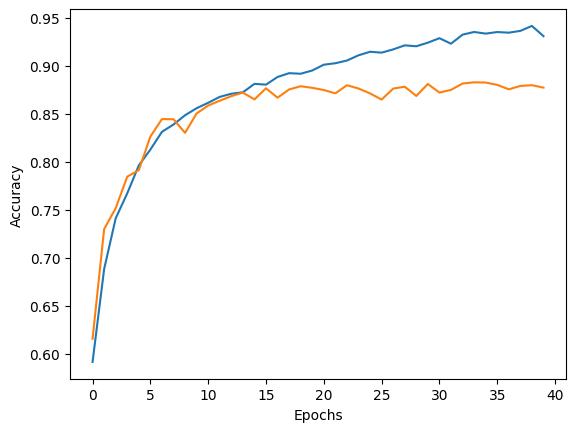

In [22]:
fig1, ax1 = plt.subplots()

ax1.plot(history['accuracy'], label='Training Accuracy')
ax1.plot(history['val_accuracy'], label='Validation Accuracy')
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Accuracy")
plt.show()

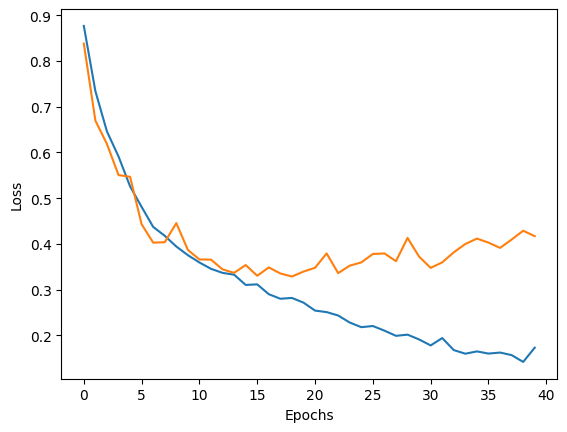

In [23]:
fig2, ax2 = plt.subplots()

ax2.plot(history['loss'], label='Training Loss')
ax2.plot(history['val_loss'], label='Validation Loss')
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss")
plt.show()

In [26]:
obj = next(iter(dataset['train']))

In [28]:
obj.keys()

dict_keys(['file_name', 'head_bbox', 'image', 'label', 'segmentation_mask', 'species'])

In [41]:
test_img, test_mask = load_img(obj)

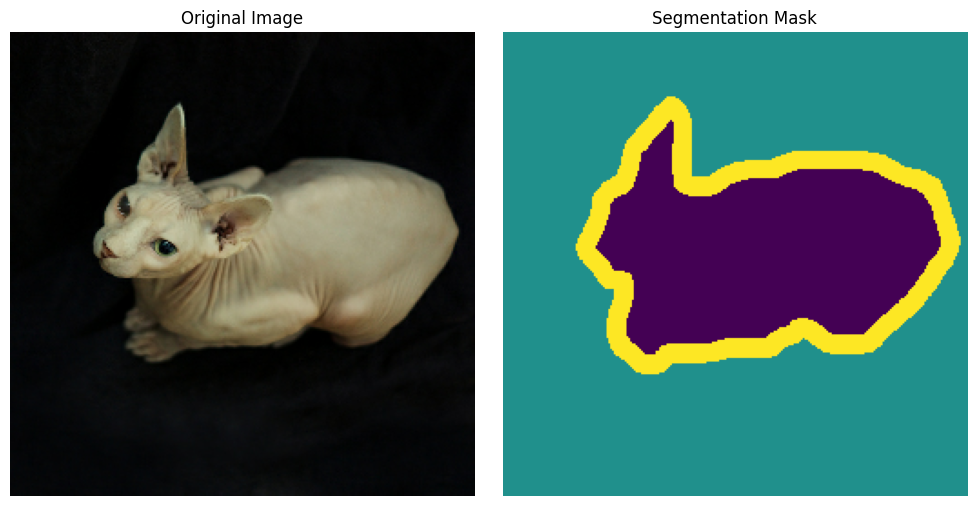

In [43]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.imshow(test_img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.imshow(test_mask, cmap='viridis') # Displaying one channel of the mask
plt.title('Segmentation Mask')
plt.axis('off')

plt.tight_layout()
plt.show()

In [44]:
test_img.shape

TensorShape([256, 256, 3])

In [45]:
test_mask.shape

TensorShape([256, 256])

In [47]:
new_img = np.expand_dims(test_img, axis=0)
prediction = model.predict(new_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [49]:
prediction.shape

(1, 256, 256, 3)

In [50]:
pred = prediction[0] # removing batch dimension
pred.shape

(256, 256, 3)

In [51]:
pred = np.argmax(pred, axis=-1) # taking the most likely value
pred.shape

(256, 256)

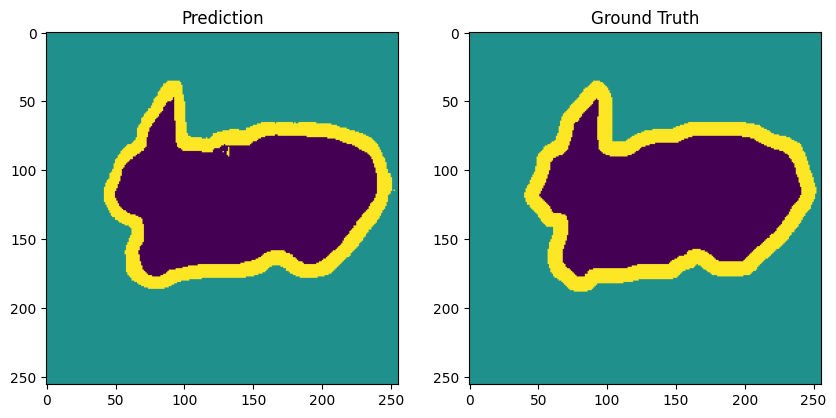

In [52]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(pred, cmap='viridis')
plt.title('Prediction')

plt.subplot(1, 2, 2)
plt.imshow(test_mask, cmap='viridis')
plt.title('Ground Truth')
plt.show()

### **Results**

We can see that the model does pretty well on a training sample, as is to be expected. The accuracy can be improved by training the model for more epochs, but this suffices as an explanation for how the model works.